Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 517ms/step - accuracy: 0.7478 - loss: 0.5758 - val_accuracy: 0.7500 - val_loss: 0.5766
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 509ms/step - accuracy: 0.8541 - loss: 0.3151 - val_accuracy: 0.7500 - val_loss: 0.6428
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 522ms/step - accuracy: 0.8854 - loss: 0.2607 - val_accuracy: 0.8125 - val_loss: 0.6698
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 540ms/step - accuracy: 0.9076 - loss: 0.2364 - val_accuracy: 0.6250 - val_loss: 1.7526
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 547ms/step - accuracy: 0.9211 - loss: 0.2073 - val_accuracy: 0.6875 - val_loss: 1.3229
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 547ms/step - accuracy: 0.9181 - loss: 0.2138 - val_accuracy: 0.6875 - val_loss: 1.0491
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 544ms/step - accuracy: 0.9019 - loss: 0.2393 - val_accuracy: 0.7500 - val_loss: 0.7045
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 540ms/step - accuracy: 0.9172 - loss: 0

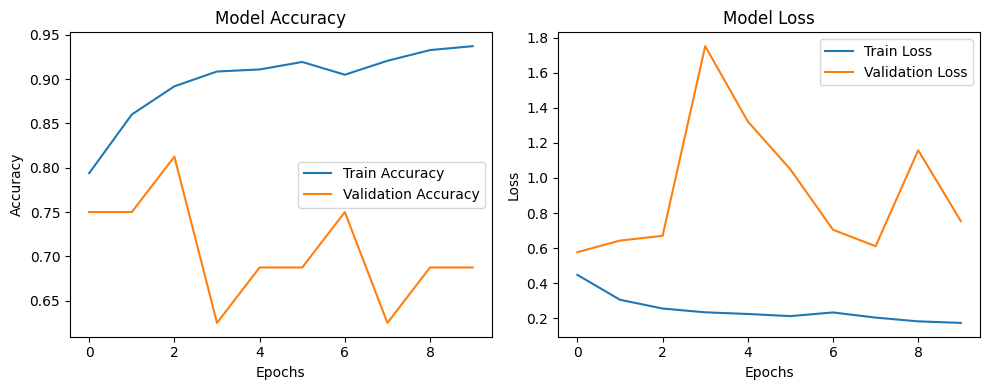

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 649ms/step - accuracy: 0.8845 - loss: 0.3396

Test Accuracy: 87.82%


In [39]:
# =====================================================
#  Import Required Libraries
# =====================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


train_dir = r"C:\Users\pratiksha sathe\Downloads\archive (3)\chest_xray\train"
val_dir = r"C:\Users\pratiksha sathe\Downloads\archive (3)\chest_xray\val"
test_dir = r"C:\Users\pratiksha sathe\Downloads\archive (3)\chest_xray\test"

# =====================================================
# Data Preprocessing
# =====================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# =====================================================
# Build CNN Model
# =====================================================
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# =====================================================
# Train the Model
# =====================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# =====================================================
#  Plot Accuracy and Loss
# =====================================================
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# =====================================================
# Evaluate on Test Data
# =====================================================
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

